In [1]:
from typing import TypedDict, Annotated
from langgraph.graph.message import AnyMessage, add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [2]:
from langchain_ollama.llms import OllamaLLM

llm = OllamaLLM(model='mistral')

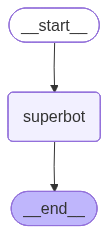

In [3]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

# Node definition
def superbot(state: State):
    return {'messages': [llm.invoke(state['messages'])]}

# Build Graph
builder = StateGraph(State)

# Node
builder.add_node('superbot', superbot)

# Edge
builder.add_edge(START, 'superbot')
builder.add_edge('superbot', END)

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

### Streaming the responses with `AStream` method

`Streaming tokens` we often want to stream more than graph state.

In particular, with chat model calls it is common to stream the `tokens` as they are generated.

We can do this using the `.astream_events` methods, which streams back events as they happen inside nodes

Each event is a dict with few keys:
- `event`: This is the type of event that is being emitted.
- `name` : This is the name of event.
- `data` : This is the data associated with the event.
- `metadata` : Containslangraph_node, the node emitted the event.

In [4]:
config = {'configurable': {'thread_id': '1'}}

async for event in graph.astream_events({'messages': ['Hey, My name is Aaron and i like to play cricket']}, config, version='v1'):
    print(event)

{'event': 'on_chain_start', 'run_id': '019d4520-88b2-7d23-9298-4365cd5a098d', 'name': 'LangGraph', 'tags': [], 'metadata': {'thread_id': '1'}, 'data': {'input': {'messages': ['Hey, My name is Aaron and i like to play cricket']}}, 'parent_ids': []}
{'event': 'on_chain_start', 'name': 'superbot', 'run_id': '019d4520-88b7-7ff0-b55a-f78ee34ff78d', 'tags': ['graph:step:1'], 'metadata': {'thread_id': '1', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:d1ec79f5-d103-236a-99ef-0e364b7b8aaa'}, 'data': {'input': {'messages': [HumanMessage(content='Hey, My name is Aaron and i like to play cricket', additional_kwargs={}, response_metadata={}, id='3c6dea38-fdda-49cf-b65d-214bb64918a1')]}}, 'parent_ids': []}
{'event': 'on_llm_start', 'name': 'OllamaLLM', 'run_id': '019d4520-88b9-7b30-94e1-da961bfe60f2', 'tags': ['seq:step:1'], 'metadata': {'thread_id': '1', 'langgr